# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [64]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# To import libraries to help with data visualization

import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
 # To read the data
path="/content/drive/MyDrive/PythonCourse/Project-Foodhub/foodhub_order.csv"
data=pd.read_csv(path)


In [ ]:
# copying data to another variable to avoid any changes to original data
df = data.copy()

In [ ]:
#  To view the first 5 rows or observations in the dataset.
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# To get the shape of the dataset with total number of rows and columns in the same.
print("There are", df.shape[0], 'rows and', df.shape[1], "columns.")

There are 1898 rows and 9 columns.


#### Observations: There are 1898 rows and 9 columns in this Food hub dataset.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# To check the different datatypes in the Food Hub dataset.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:



*   There are 4 object datatype columns and 5 numerical datatypes.
*   All the columns have 1898 observations, which denotes there are no null values in all the columns.
*   The 5 numeric datatype columns are as order_id, customer_id, cost_of_the_order, food_preparation time and delivery_time.
*   The 4 object datatype columns are restaurant_name, cuisine_type, day_of_the_week and rating
*   The rating column declared as 'Object' datatype denotes an ambiguity for future data analysis. Possible conversion of this column to integer datatype is more meaningful for analysis.












In [ ]:
# checking for any duplicate values or rows in the dataset
df.duplicated().sum()

np.int64(0)

There are no duplicate values or rows in the dataset.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# To find missing values in the data set
df.isnull().sum().sum()


np.int64(0)

#### Observations:

Ther are no missing values in the given Food Hub dataset.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# To get the statistical summary of the dataset.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:



*   Minimum time taken for food preparation is 20 minutes.
*   The mean or the average time taken for food preparation is around 27.37 minutes.
*   Maximum time taken for food preparation is 35 minutes.
*   Cost of the order ranges from a minimum of 4.47 dollars to a maximum of 35.41 dollars.
*   Order_id are just labels unique for every row in the dataset.














To find the number of unique entries for the order_id column.

In [ ]:
df['order_id'].nunique()

1898

There are 1898 unique values of order_id indicating the same number of rows as in the dataset and it is an unique identifier.

Let us drop the order_id column from our dataset as it will not add any value to our analysis since it is an unique identifier.


In [ ]:
df.drop('order_id', axis=1, inplace=True)

Print the head of the dataset to verify that the order_id column has been successfully dropped.

In [ ]:
df.head()

,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# To find how many orders are not rated using the value_counts function.
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:

There are totally 736 orders not rated from the observation as 736 entries in the dataset has the value 'Not given'.




 **Fixing the data type for 'rating' column in the dataset as it is specified as Object type**.



  Converting the column to integer data type will be useful for further data analysis.

 Following lines of code are used for converting the whole 'rating' column to integer datatype.

Let us replace the value ' Not given ' in the column ' rating' to NaN

In [ ]:
#Let us replace the value ' Not given ' in the column ' rating' to NaN
df['rating'] = df['rating'].replace(['Not given'],np.nan)


Checking to see if the values 'Not given' is replaced by NaN values using value_counts for the 'rating' column.

In [ ]:
df['rating'].value_counts(dropna=False)

,count
rating,
NaN,736
5,588
4,386
3,188


In [ ]:
#Let us print the rows where the  'rating' column is having missing values
df.loc[df['rating'].isnull()==True]

,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
6,157711,The Meatball Shop,Italian,6.07,Weekend,NaN,28,21
10,143926,Big Wong Restaurant _¤¾Ñ¼,Chinese,5.92,Weekday,NaN,34,28
14,62667,Lucky's Famous Burgers,American,12.13,Weekday,NaN,23,30
...,...,...,...,...,...,...,...,...
1887,237616,Shake Shack,American,5.82,Weekend,NaN,26,30
1891,138586,Shake Shack,American,5.82,Weekend,NaN,22,28
1892,97838,Han Dynasty,Chinese,29.15,Weekend,NaN,29,21
1895,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,NaN,31,24


A total of 736 rows with NaN values for the 'rating' column.

Converting the entire 'rating' column to integer by replacing the NaN value to zeroes.

In [ ]:
# Converting whole column to integer by replacing the NaN value to 0
df['rating'] = df['rating'].fillna(0).astype(int)

Checking to see if NaN values are replaced by zeroes in the 'rating ' column.

In [ ]:
df['rating'].value_counts()

,count
rating,
0,736
5,588
4,386
3,188


Checking to see the if the 'rating' column has been converted to integer datatype.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1898 non-null   int64  
 1   restaurant_name        1898 non-null   object 
 2   cuisine_type           1898 non-null   object 
 3   cost_of_the_order      1898 non-null   float64
 4   day_of_the_week        1898 non-null   object 
 5   rating                 1898 non-null   int64  
 6   food_preparation_time  1898 non-null   int64  
 7   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 118.8+ KB


The rating column has been converted to integer data type.

Checking to see there are no rows with rating column having any null values (NaN values)

In [ ]:
df.loc[df['rating'].isnull()==True]

,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


No rows are displayed satisfying the condition for the rating column having null values.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

####  **Understanding the distribution of each of the columns in the dataset for further analysis. Let us first analyse the numerical columns now.**








####  **Understanding the distribution of customer_id**








In [ ]:
df['customer_id'].nunique()

1200

Observations :
There are a total of 1200 different customers identified in the dataset.


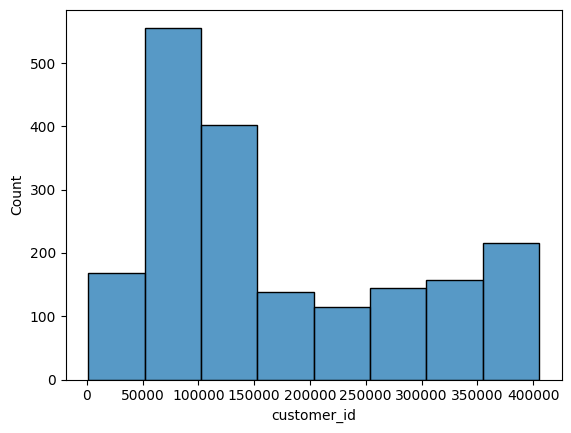

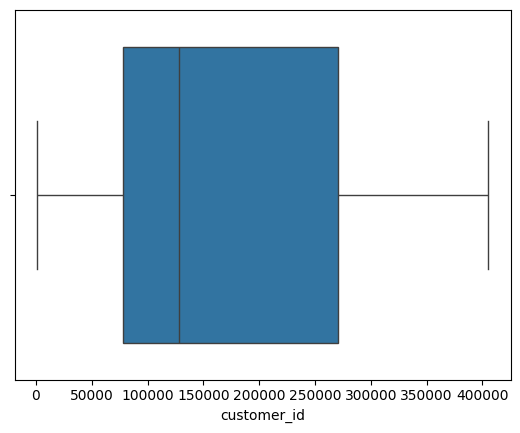

In [ ]:
# Exploring the customer id in the database
sns.histplot(data=df,x='customer_id',binwidth=50000)
plt.show()
sns.boxplot(data=df,x='customer_id')
plt.show()

Observations:

Customer_id is a unique id given to various 1200 customers.

 Understanding the unique id distribution does not make sense in further univariate analysis of customer_id.


####  **Understanding the distribution of cost_of_the_order**








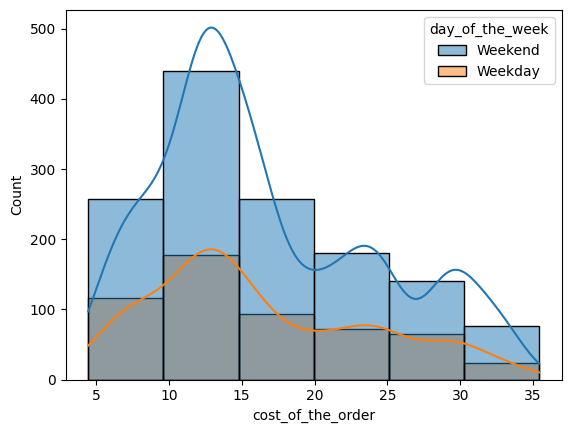

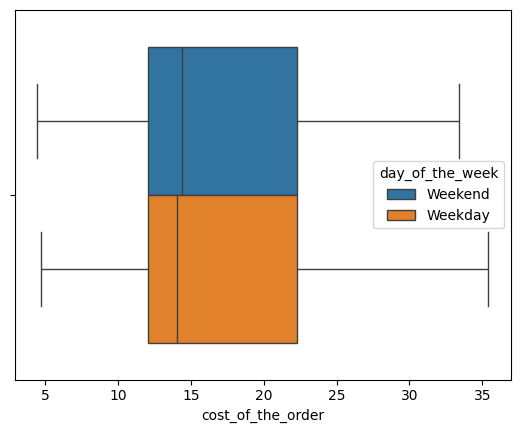

In [ ]:
# Exploring the spread of the cost of the orders that was placed in the database

sns.histplot(data=df,x='cost_of_the_order',binwidth=5,kde='True',hue='day_of_the_week')
plt.show()


sns.boxplot(data=df,x='cost_of_the_order',hue='day_of_the_week')
plt.show()



In [ ]:
#To find the median
print('Median of the cost of the order is ', df['cost_of_the_order'].median())

Median of the cost of the order is  14.14


Observations :

The cost of the order looks right skewed.

The minimum cost is less than 5 dollars and the maximum is around 35 dollars.

The median is around 14.14 dollars.

50 percent of the cost of the order is between 12 dollars and 22 dollars.

We can also observe weekend , there are higher number of orders than weekdays!


####  **Understanding the distribution of rating column**








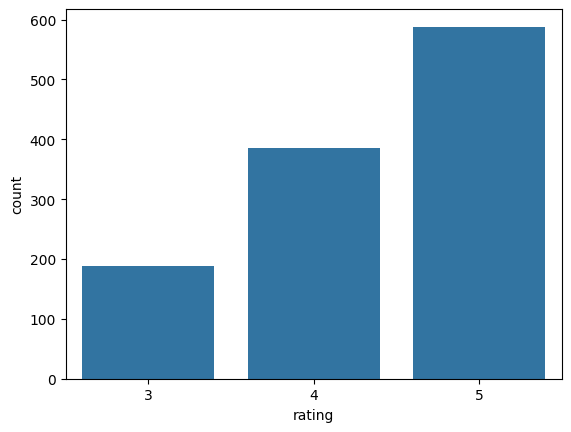

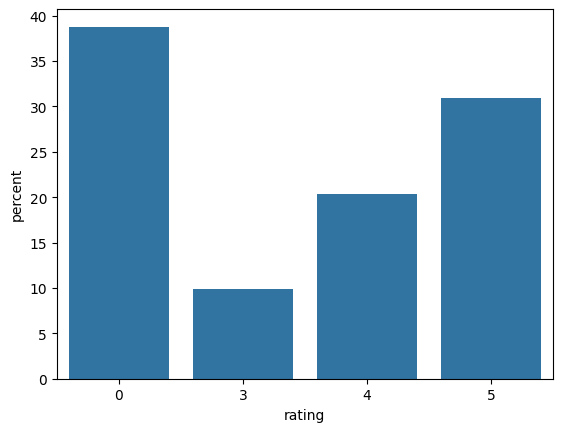

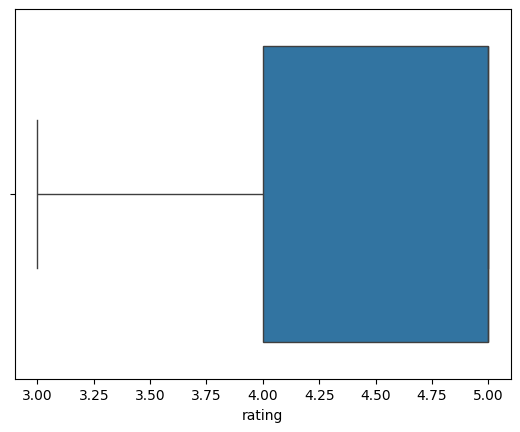

rating
0    736
5    588
4    386
3    188
Name: count, dtype: int64


In [ ]:
# Exploring the spread of the ratings by various customers in the database
#To exclude the 'rating' variables with values 0 in the same while displaying countplot and boxplot graphs
df_excl_0 = df[df['rating']!= 0]
sns.countplot(data=df_excl_0,x='rating')
plt.show()
sns.countplot(data=df,x='rating',stat='percent')
plt.show()
sns.boxplot(data=df_excl_0,x='rating')
plt.show()
rating_counts = df['rating'].value_counts()
print(rating_counts)

Observations:


Highest rating that was given was 5.
Median rating is 4.

Around 736 orders were not rated.

About 30 %, which is less than 600 orders had a rating of 5. (588 orders)

Around 20 %, which is less than 400 orders had a rating of 4. (386 orders)

About 10% , which is less than 200 orders had a rating of 3. (188 orders)

Closer to 40% of the total customers who have not given any rating for the food orders. This is something that could be looked at !





####  **Understanding the distribution of food_preparation_time**








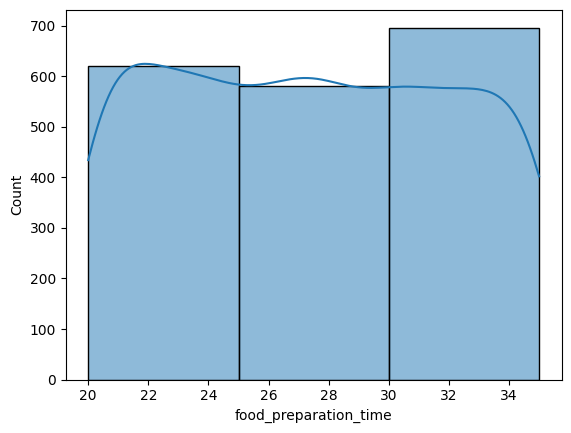

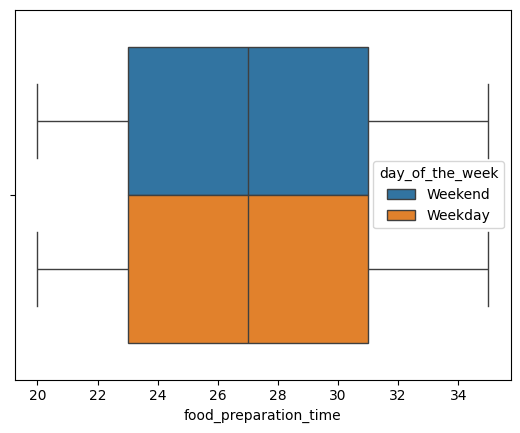

In [ ]:
# Exploring the spread of the food preparation time  in the database
sns.histplot(data=df,x='food_preparation_time',bins=3,kde=True)
plt.show()
sns.boxplot(data=df,x='food_preparation_time',hue='day_of_the_week')
plt.show()

Observations:

Looks like a uniform distribution from the upper portion of the graph in the histplot.

The food preparation time varies from a minimum of 20 minutes to a maximum of around 35 minutes.

The median time is 27 minutes.

Around 600 orders took 25 minutes on an average to prepare food.

Less than 600 orders took between 25 minutes and 30 minutes to prepare food.

Around 700 orders took between 30 minutes and 35 minutes to prepare food.




####  **Understanding the distribution of delivery_time**








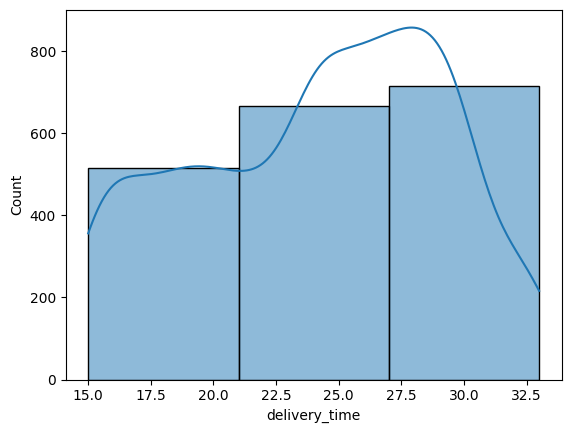

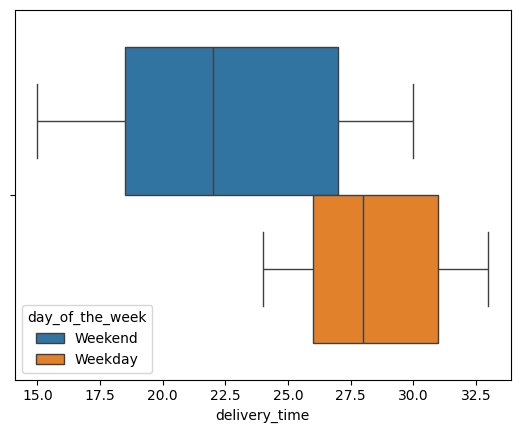

In [ ]:
# Exploring the spread of the delivery time  in the database
sns.histplot(data=df,x='delivery_time',bins=3,kde=True)
plt.show()
sns.boxplot(data=df,x='delivery_time',hue='day_of_the_week')
plt.show()

Observations :

The delivery_time column is slightly left skewed.

The median delivery time is 25 minutes.

It takes between 15 minutes and 33 minutes for the orders to be delivered.Maximum time taken is around 33 minutes for the order to be delivered.

For around 700 orders  placed it takes anywhere between 27 minutes and 33 minutes for the order to be delivered.

50 % of the delivery time ranges anywhere from 20 minutes to 28 minutes.

From the boxplot graph we can infer that weekday delivery time is more than weekend delivery time. It could be due to working weekdays where more number of people commute  and henceforth due to traffic.

### Exploring categorical variables in the dataset.

####  **Understanding the distribution of restaurant_name**








In [ ]:
df['restaurant_name'].nunique()

178

In [ ]:
df['restaurant_name'].value_counts()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


 Observations :

   There are totally 178 unique restaurants in the area. The value counts gives the distribution of the restaurant names and the corresponding order counts in the database.

####  **Understanding the distribution of the cuisine_type**








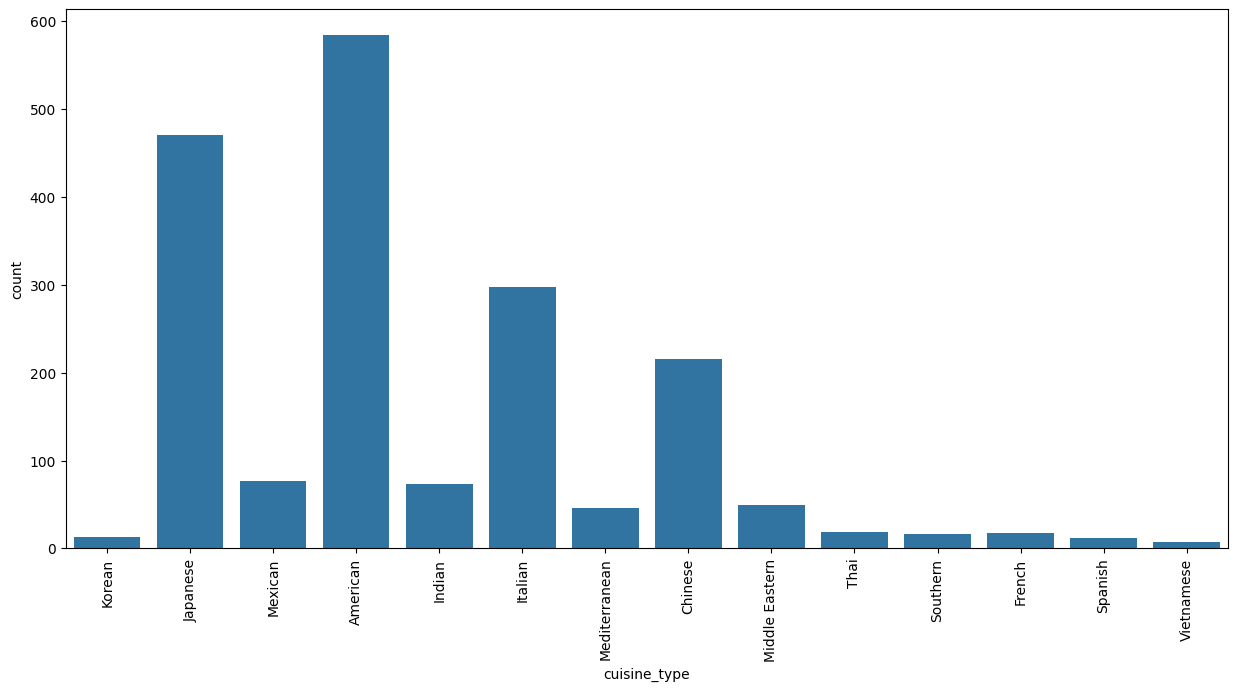

In [ ]:
# Exploring the different cuisines that was ordered by the customers in the database
plt.figure(figsize=(15,7))
sns.countplot(data=df,x='cuisine_type');
plt.xticks(rotation = 90);

In [ ]:
df['cuisine_type'].value_counts()



,count
cuisine_type,
American,584
Japanese,470
Italian,298
Chinese,215
Mexican,77
Indian,73
Middle Eastern,49
Mediterranean,46
Thai,19


Observations:


Maximum orders were from the American cuisine type ( 584), followed by Japanese(470), Italian(298) and Chinese(215).

Few orders were also placed from Mexican and Indian Cuisine types including Mediteranean and middle eastern cuisine following them.

Other cuisine types had minimal orders.

Popular cuisine types in this area were American and Japanese, to an extent with Italian followed by Chinese.


####  **Understanding the distribution of day_of_the_week**








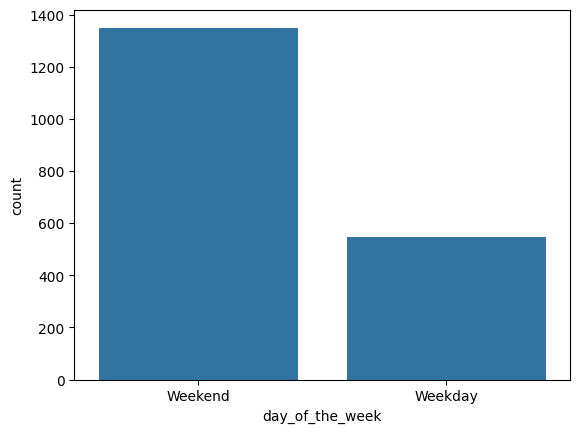

In [ ]:
# Exploring the days of the week when the orders were placed by the customers in the database
sns.countplot(data=df,x='day_of_the_week');


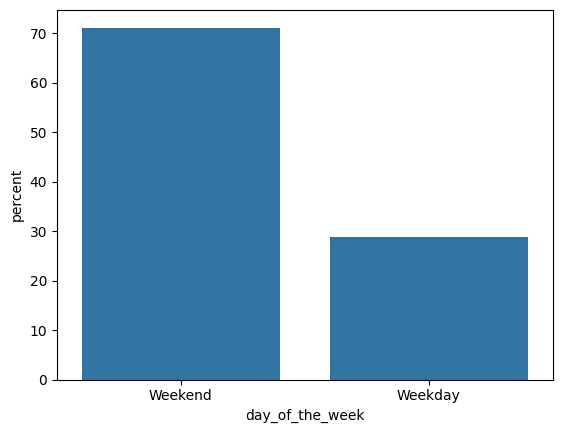

In [ ]:
sns.countplot(data=df,x='day_of_the_week',stat='percent');


In [ ]:
df['day_of_the_week'].value_counts()

,count
day_of_the_week,
Weekend,1351
Weekday,547


Observations :

70 % of the orders were placed in Weekends compared to slighltly less than 30 % of weekday orders.

Weekday orders approximates close to 500 plus orders(541) whereas Weekend orders were in between 1300 and 1400 orders(1351).

The Food Hub App is used more during the weekends to order food.


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
top5_restaurants = df['restaurant_name'].value_counts()
top5_restaurants.head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
The top 5 restaurants out of a total of 178 restaurants, in terms of the number of orders received are :-

1. Shake Shack - 219 orders received
2. The Meatball Shop - 132 orders received
3. Blue Ribbon Sushi - 119 orders received
4. Blue Ribbon Fried Chicken - 96 orders received
5. Parm - 68 orders received




### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

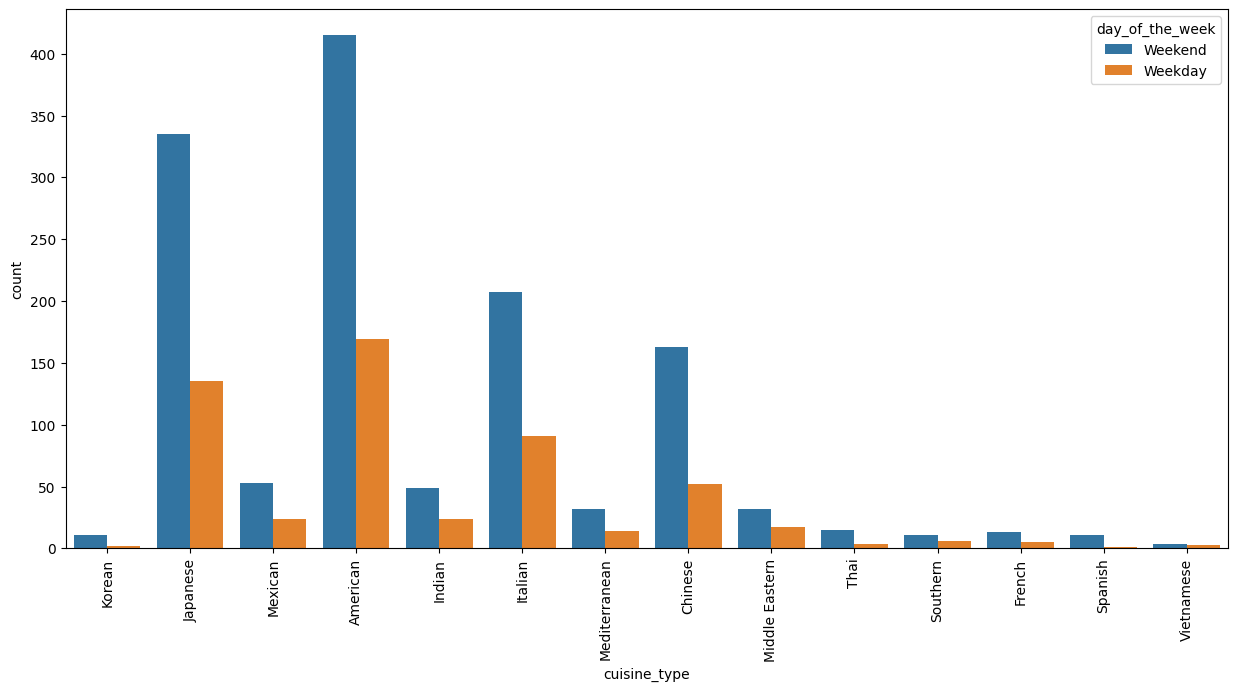

In [ ]:
plt.figure(figsize=(15,7))
sns.countplot(data=df,x='cuisine_type',hue='day_of_the_week');
plt.xticks(rotation = 90);

#### Observations:

American Cuisine type is the most popular Cuisine over the weekends, followed by Japanese, Italian and Chinese cuisine types.



### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
df['cost_of_the_order'].value_counts()


,count
cost_of_the_order,
12.18,86
12.13,82
12.23,47
24.20,42
29.10,37
...,...
7.66,1
10.86,1
7.95,1


In [ ]:
percentage_order = df['cost_of_the_order'] > 20
percentage_order.value_counts(normalize=True) * 100


,proportion
cost_of_the_order,
False,70.758693
True,29.241307


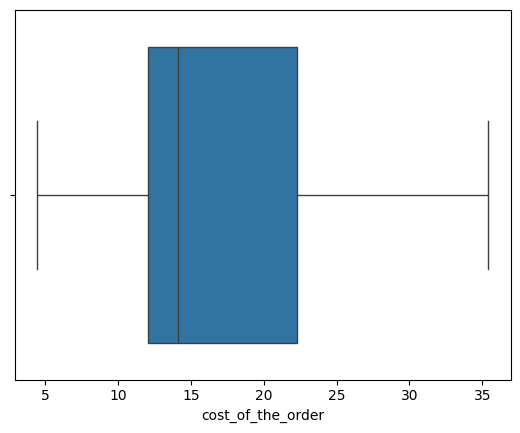

In [ ]:
sns.boxplot(data=df,x='cost_of_the_order')
plt.show()

#### Observations:

**29.24 percent of the orders cost more than 20 dollars.**



### **Question 10**: What is the mean order delivery time? [1 mark]

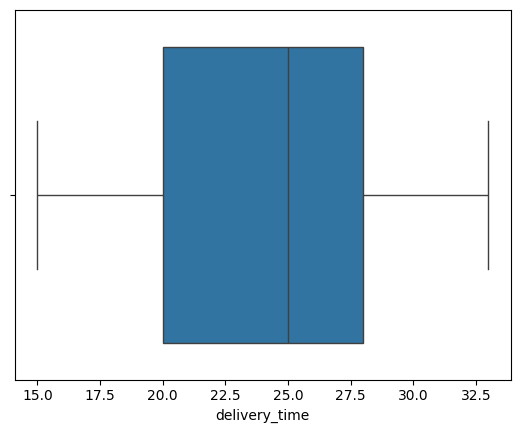

24.161749209694417


In [ ]:
# Write the code here
sns.boxplot(data=df,x='delivery_time')
plt.show()
df.describe()
mean_delivery_time = df['delivery_time'].mean()
print(mean_delivery_time)

#### Observations:
24.16 minutes is the mean delivery time , which is the time taken by the delivery person for the prepared food to be delivered to the customer once the food is prepared by the restaurant.




### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
df['customer_id'].value_counts()


,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7
...,...
143926,1
89574,1
157711,1


#### Observations:
  Customer ids with the numbers 52832, 47440 and 83287 are the top 3 most frequent customers.

  Top 3 most frequent Customers and their respective number of orders :-
   1. Customer id 52832 placed 13 orders.
   2. Customer id 47440 placed 10 orders
   3. Customer id 83287 placed 9 orders
    


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


#### **Correlation by Heatmap**

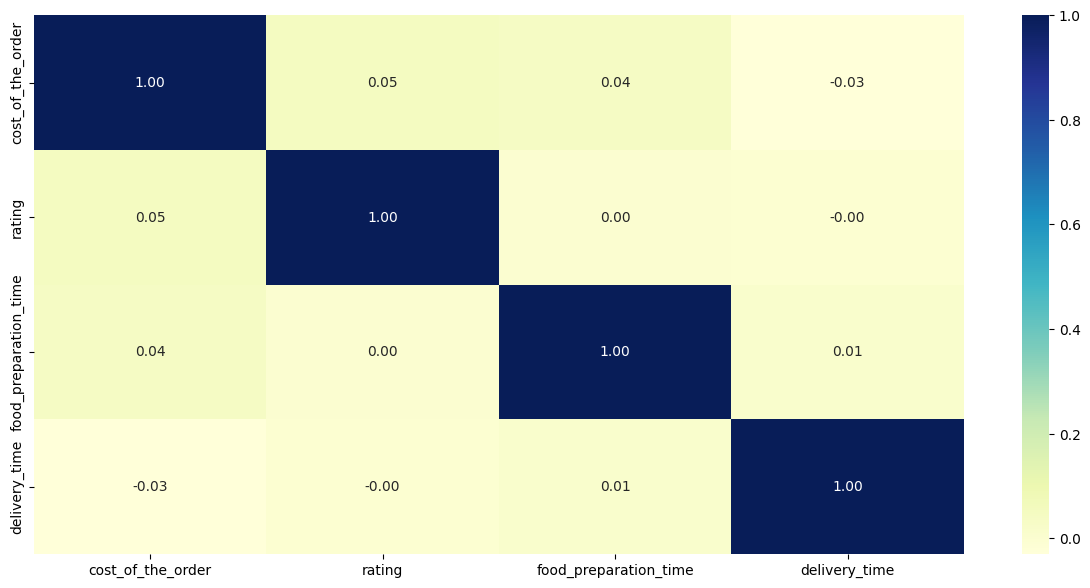

In [ ]:
# Check for correlation among numerical variables

# plot the heatmap

plt.figure(figsize=(15, 7))
sns.heatmap(data=df[['cost_of_the_order','rating','food_preparation_time','delivery_time']].corr(), annot=True,fmt=".2f",cmap='YlGnBu');
plt.show()


##### Observations:
  The correlation  map  of  the numerical variables does not give sufficient amount of data to find any relationship between the numerical columns.Unable to decipher or analyse much of the correlation from the above matrix of the numerical variables.

#### **Food_preparation_time to Delivery_time relationship**

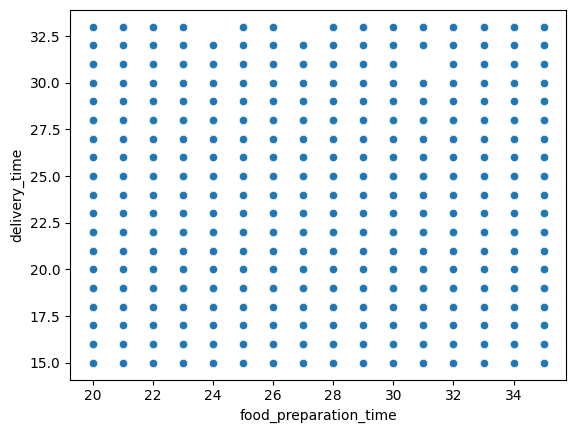

In [ ]:
sns.scatterplot(data=df, x='food_preparation_time', y='delivery_time');


##### Observations:
We find that there is no correlation between the food_preparation time and delivery time.

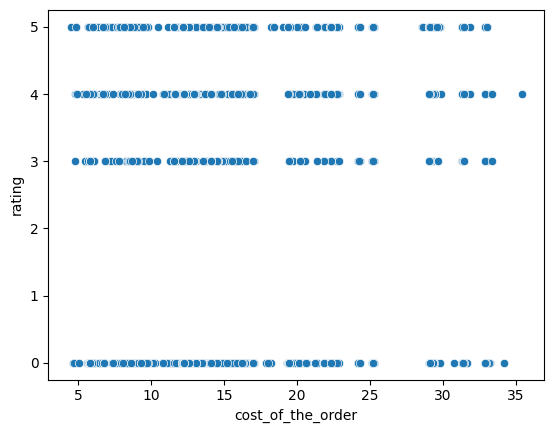

In [ ]:
sns.scatterplot(data=df, x='cost_of_the_order', y='rating');

Observations : - Reiterating from the heatmap matrix that there is no correlation between the numerical vairables - cost of the order and rating!

#### **Cost of order(Numercial variable) to Cuisine Type( Categorical variable) relationship**

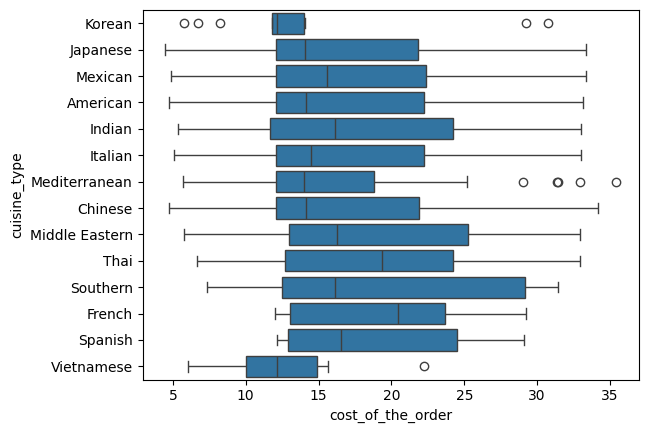

In [ ]:
sns.boxplot(data=df, y='cuisine_type', x='cost_of_the_order');

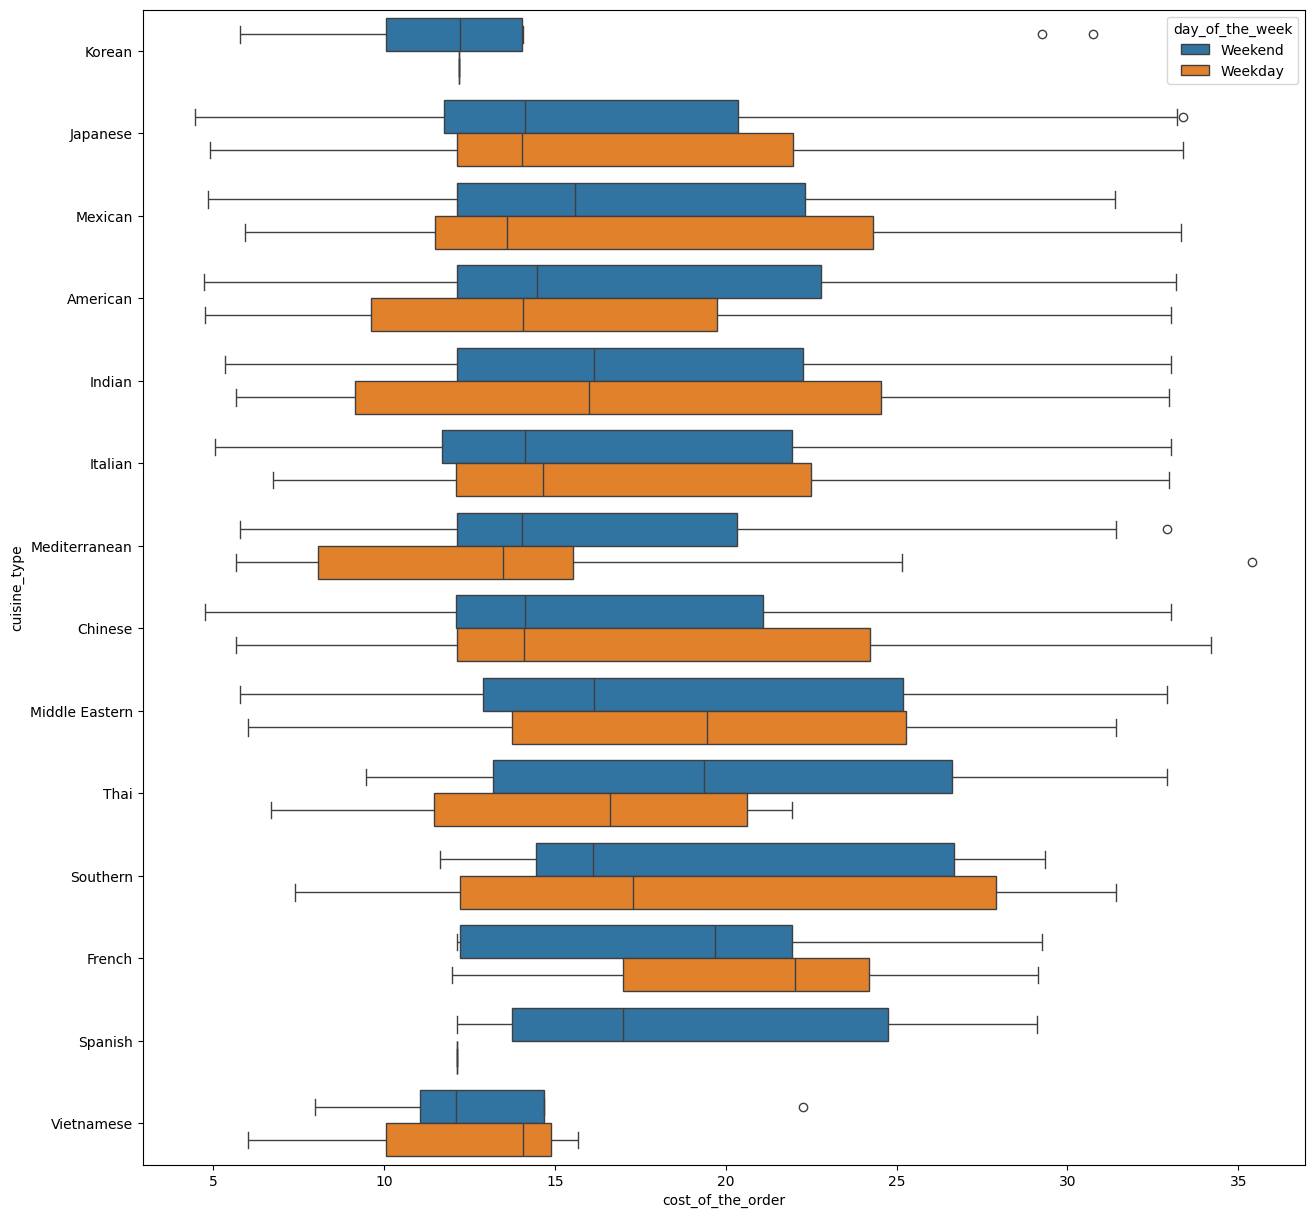

In [ ]:
plt.figure(figsize=(15, 15))
sns.boxplot(data=df, y='cuisine_type', x='cost_of_the_order',hue='day_of_the_week');

In [ ]:
max_cost = df['cost_of_the_order'].max()
print('Maximum cost of the order in the food hub dataset is ', max_cost)

df.loc[df['cost_of_the_order'] == max_cost]

Maximum cost of the order in the food hub dataset is  35.41


,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
573,62359,Pylos,Mediterranean,35.41,Weekday,4,21,29


##### Observations:
The range in Cost of the order for most of the cuisine types look very similar and evenly spread including the most popular ones like American, Japanese, Italian including Indian.


Vietnamese and Korean cuisine types is the cheapest of all and also least popular.

There are some outliers in the mediterranean and one in Korean.
We can see the maximum cost of $35.41 which is shown as outlier in the graph is for the mediterranean cuisine type which is less popular.

We can also see some weekday orders of certain cuisine types like Indian, southern have more orders than weekend orders of the same cuisine types.

But the spread of orders for most of the cuisine types are very similar in both weekend and weekdays!



  #### Rating( Numerical variable) to Cuisine Type relationship ( Categorical variable)


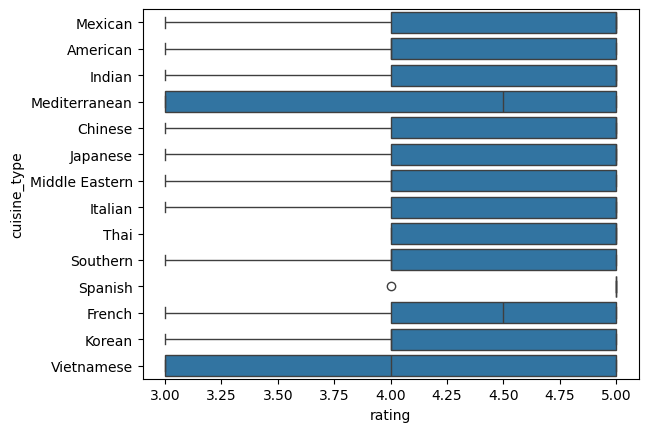

In [ ]:
sns.boxplot(data=df[df['rating']!=0],x='rating',y='cuisine_type');

##### Observations:
Vietnamese and Mediterranean cuisine types have the lowest rating of 3.
All the other cuisine types have ratings between 4 & 5 .

Vietnamese is also less popular and the cheapest of all. It could infer low quality of the food too with rating also being low.

Mediterranean too has low rating of 3 and less popular, even though there is outlier of higher cost in this cuisine type, this probably could infer of some low quality food in this cuisine type restaurant also.

####  Cuisine Type( Categorical Variable) and  Food preparation time ( Numerical variable) relationship.

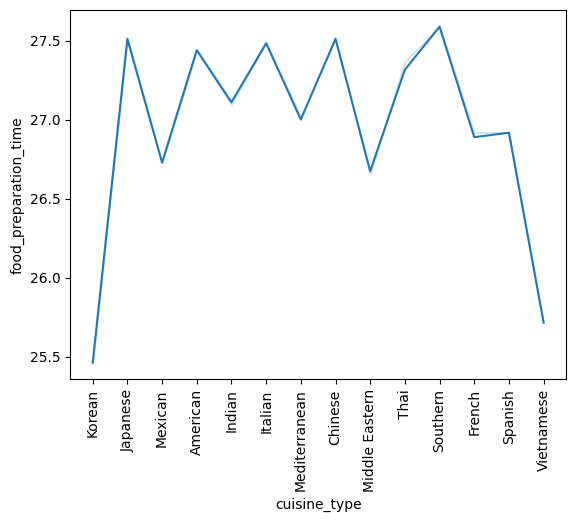

In [ ]:
sns.lineplot(data=df, x='cuisine_type', y='food_preparation_time', errorbar = ('ci',False))
plt.xticks(rotation = 90);

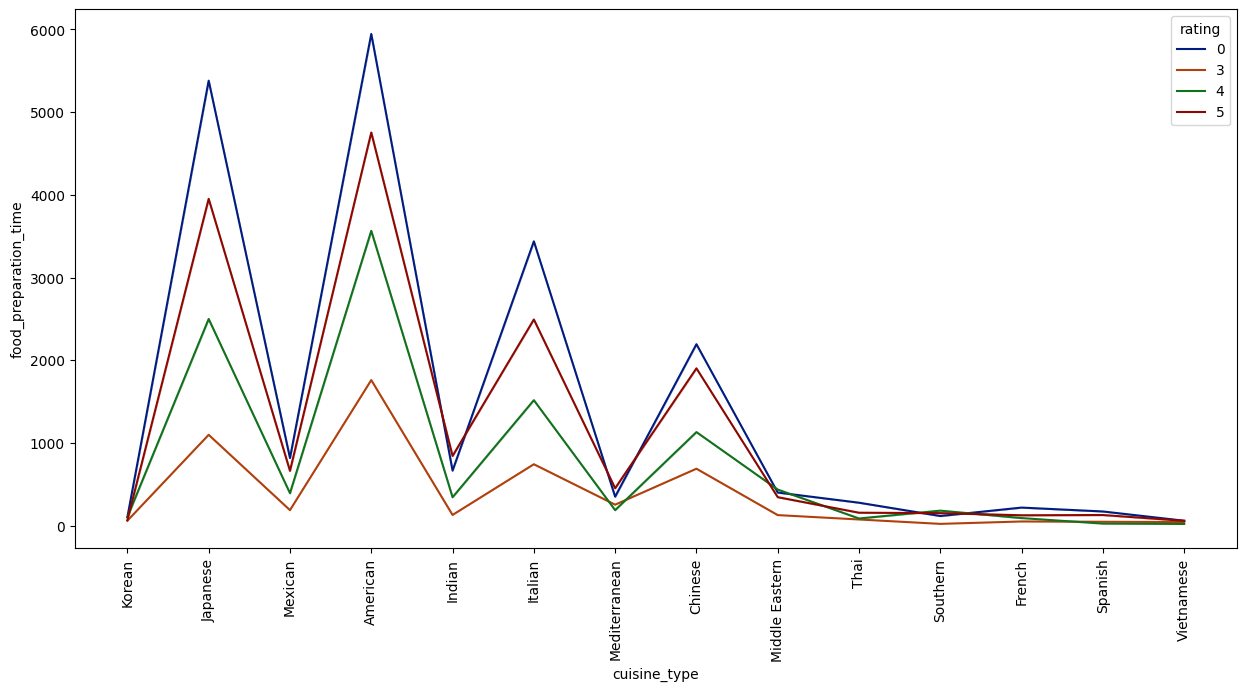

In [ ]:
plt.figure(figsize=(15,7))
sns.lineplot(data=df, x='cuisine_type',y='food_preparation_time',estimator = 'sum',hue='rating',palette='dark', errorbar = ('ci',False))
plt.xticks(rotation = 90);

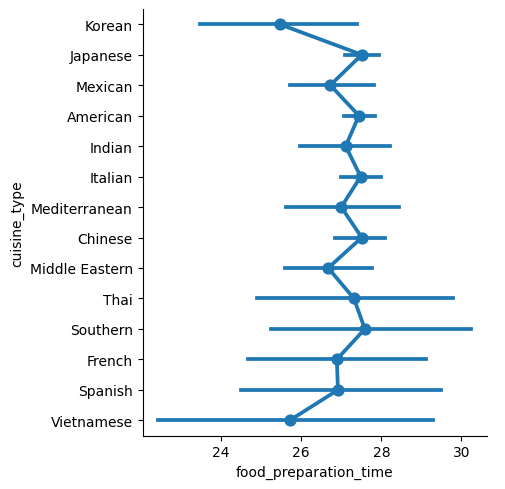

In [ ]:


sns.catplot(data=df, x='food_preparation_time', y='cuisine_type', kind='point')
plt.show()




##### Observations:

  As we can see from the graphs the popular cuisines have consistent food preparation time - American, Japanese, Italian and Chinese followed by Southern by observing the peaks in the line plot. Customers prefer these cuisines probably due to consistency in their preparation timings and have good ratings and probability of these ethnicity to be taken into consideration.


  Mexican, Indian, Mediterranean and middle eastern are midway in their timings.

  Korean and Vietnamese takes least food preparation time compared to other cuisine types.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here

#To create dataframe excluding the zero values in the rating for calculating the given criteria in the above question

df_excl_0 = df[df['rating']!= 0]

#Finding all the restaurants in the dataframe df_excl_0 with the rating count more than 50 and assigning it to the variable rate_count50
rate_count50 = df_excl_0.groupby('restaurant_name')['rating'].transform('count') > 50

# finding all the rows with rating greater than 4 in the dataframe df_excl_0
rating_value = df_excl_0['rating'] > 4

# creating a filtered dataframe satisying the 2 conditions with rating greater than 4 and having rating counts of more than 50
filtered_df = df_excl_0.loc[rate_count50 & rating_value]

#Now finding the unique restaurant names satisfying the above conditions
filtered_df['restaurant_name'].unique()



array(['Blue Ribbon Fried Chicken', 'Shake Shack', 'The Meatball Shop',
       'Blue Ribbon Sushi'], dtype=object)

#### Observations:

The following restaurants will get the promotional offer provided by the company FoodHub as they meet the criteria with rating value  greater than 4 and more than 50 ratings  

1. Blue Ribbon Fried Chicken
2. Shake Shack
3. The Meatball Shop
4. Blue Ribbon Sushi


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
df_cost_20 = df['cost_of_the_order'] > 20
df_cost_betwn_5_and_20 = (df['cost_of_the_order'] > 5)  & (df['cost_of_the_order']  <=20)

df_cost_20_num = df_cost_20.sum()
print('Number of orders where the cost is greater than 20 is ', df_cost_20_num)

total_df_cost_20 = df[df_cost_20]['cost_of_the_order'].sum()
print('Total amount where the cost is greater than 20 is ',total_df_cost_20)

df_cost_betwn_5_and_20_num =  df_cost_betwn_5_and_20.sum()
print('Number of orders where the cost is between 5 and 20 is ',df_cost_betwn_5_and_20_num)

total_df_cost_betwn_5_and_20 = df[df_cost_betwn_5_and_20]['cost_of_the_order'].sum()
print('Total amount where the cost is between 5 and  20 is ',total_df_cost_betwn_5_and_20)

net_revenue = (total_df_cost_20 * 0.25) + (total_df_cost_betwn_5_and_20 * 0.15)
print('The total net revenue by the company is ', net_revenue)





Number of orders where the cost is greater than 20 is  555
Total amount where the cost is greater than 20 is  14754.91
Number of orders where the cost is between 5 and 20 is  1334
Total amount where the cost is between 5 and  20 is  16517.170000000002
The total net revenue by the company is  6166.303


#### Observations:

The net revenue generated by the company is 6166.303 across all the orders in the dataset.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
df['total_delivery_time']  = df['delivery_time'] + df['food_preparation_time']
total_60 = df['total_delivery_time'] > 60
df.loc[total_60]
total_60.value_counts(normalize=True) * 100




,proportion
total_delivery_time,
False,89.462592
True,10.537408


#### Observations:
Almost  10.54 % of the orders take more than 60 minutes to get delivered from the time the order is placed.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

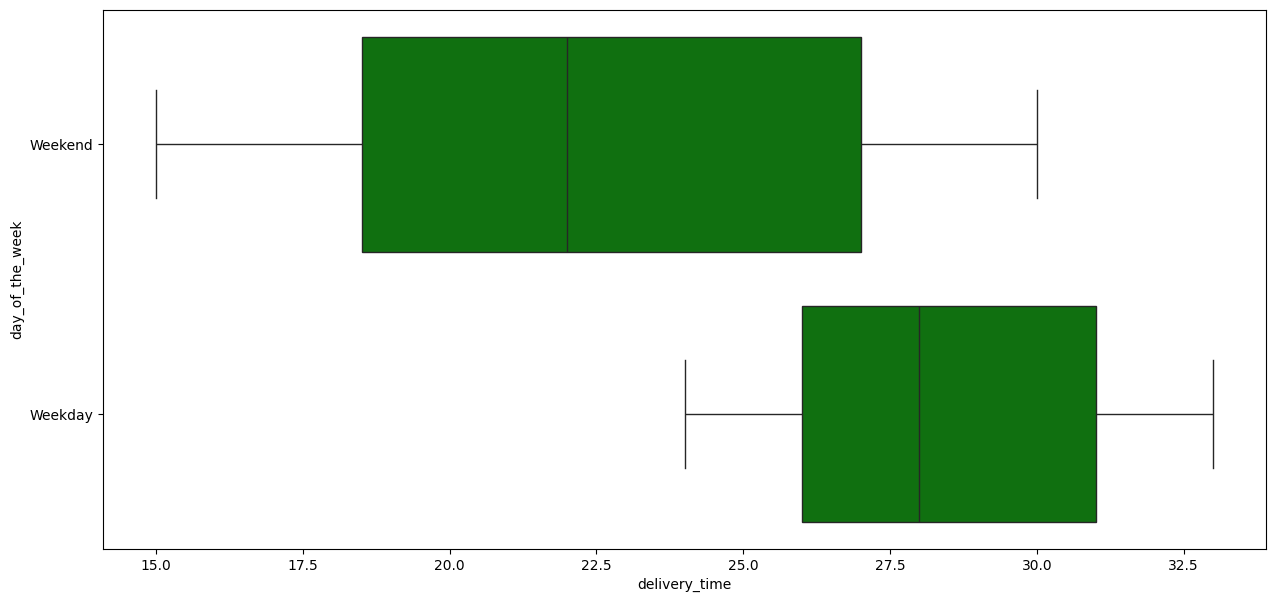

In [ ]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=df,x='delivery_time',y='day_of_the_week',color='green')
plt.show()

In [ ]:
df.groupby(['day_of_the_week'])['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


In [ ]:
# To find if the days of the week has values other than ' weekend'/ 'weekday' using the value_counts function.
df['day_of_the_week'].value_counts()

,count
day_of_the_week,
Weekend,1351
Weekday,547


#### Observations:


*   Weekend orders delivery time is slightly better and faster than the weekday orders comparitively.

*   The mean delivery time is around 22 minutes over the weekend and 28 minutes during the weekday.
   
*   Also, there are more number of orders in the weekends compared to weekdays as we explored in the univariate analysis for the counts ( number of orders) for the day of the week.Weekends had 1351 orders placed and Weekday 547 orders placed.
  
*   In general, weekends have more orders placed than weekdays!





  
  


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  In general, weekends have more orders placed than weekdays!
  70% orders during weekends and less than 30% on weekdays.

  * 10.54 % of the orders take more than 60 minutes to get delivered from the time the order is placed.

  * Delivery time is better during the weekends than weekdays comparitively. This could be due to office working days and traffic timings during the weekdays!

  * American cuisine is the most popular cuisine type followed by Japanese, Italian and Chinese. Probably the distribution could be based on the ethnicity in that region and hence the popularity and preference of cuisines by the customers.

  
  * The top 5 restaurants preferred by the customers are namely Shake Shack ,
    The Meatball Shop ,Blue Ribbon Sushi , Blue Ribbon Fried Chicken and Parm.

  * Median food preparation time is around 27 minutes and the median delivery time is 25 minutes. Totally it takes on an average around 52 minutes for the food to reach the customer once it is ordered. Definitely speeding up this process will attract more customers for the app.

  * 60 percent of the customers have given ratings for the restaurants between 3 & 5.  Around 40% of the total customers did not give any rating for the food orders.

  * Cost of the orders range from 5 to 35 in total.Cost is evenly spread among different cuisine types including the most popular ones like American, Japanese and  Italian.

  * The company is giving promotional offers mainly to those restaurants which are already popular amongst the customers and also has higher number of ratings like Blue Ribbon Fried Chicken, Shake Shack ,The Meatball Shop and Blue Ribbon Sushi.



  







  
    







### Recommendations:

###  Adverstising and target marketing can be improved

*  Advertising and marketing better for other non-popular restaurants and cuisine types through the app by giving promotional offers will attract more customers from diverse ethnicity. Target marketing will improve the usage of the app.
  The company is giving promotional offers ONLY to popular restaurants with higher number of ratings instead if they give these offers to other restaurants as well, their reach will be more inspite of the ratings.


###  Delivery time can be improved

*    Delivery time can be worked on better and reduce the time to deliver by 30
     minutes.  
     The food hub can suggest the restaurants for adding or including menus like mini bytes which can be made in a shorter preparation time and hence can be delivered faster to the customers. This will help in increasing the number of orders placed by the app due to food reaching faster and also inturn help in adding more revenue to the app by the frequency of the usage.

###  Adding speciality / unique menus by low performing restaurants and cuisines



*   The food hub can also recommend low performing
      cuisine types/ restaurants
      to add unique speciality menus from their cuisines through good advertisements to attract more customers.


      

###  The number and count of ratings can be improved!


     

*   As only 60 % of the customers are giving ratings, to attract more
     customers to rate the different cuisine types/ restaurants - any attraction marketing to increase the number of ratings would help the usage of the app more for the customers to get attracted to other restaurants.




     

---